# Phase 2 and 3: Clean Baseline CNN for CIFAR-100 Fox vs Wolf

This Colab notebook mounts Google Drive, loads CIFAR-100 locally, prepares fox/wolf splits, trains a simple CNN, saves the best checkpoint, plots learning curves, and evaluates on the untouched test set.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import json, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

DATA_ROOT = Path('/content/drive/MyDrive/Datasets')
OUTPUT_DIR = Path('/content/drive/MyDrive/NMA_Occlusion_Project')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
BATCH_SIZE = 64
NUM_WORKERS = 2
VALIDATION_FRACTION = 0.20
EPOCHS = 20
LEARNING_RATE = 1e-3

assert (DATA_ROOT / 'cifar-100-python').exists(), 'CIFAR-100 folder not found.'
print('Dataset folder:', DATA_ROOT)
print('Output folder:', OUTPUT_DIR)


Dataset folder: /content/drive/MyDrive/Datasets
Output folder: /content/drive/MyDrive/NMA_Occlusion_Project


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## Load and filter CIFAR-100

In [4]:
cifar_train_full = datasets.CIFAR100(root=str(DATA_ROOT), train=True, download=False)
cifar_test_full = datasets.CIFAR100(root=str(DATA_ROOT), train=False, download=False)
print(len(cifar_train_full), len(cifar_test_full))

original_class_ids = {
    'fox': cifar_train_full.class_to_idx['fox'],
    'wolf': cifar_train_full.class_to_idx['wolf'],
}
old_to_new = {original_class_ids['fox']: 0, original_class_ids['wolf']: 1}
print('Original IDs:', original_class_ids)
print('Binary mapping:', old_to_new)


50000 10000
Original IDs: {'fox': 34, 'wolf': 97}
Binary mapping: {34: 0, 97: 1}


In [5]:
train_targets = np.asarray(cifar_train_full.targets)
test_targets = np.asarray(cifar_test_full.targets)
selected_ids = list(old_to_new.keys())
all_train_indices = np.where(np.isin(train_targets, selected_ids))[0]
test_indices = np.where(np.isin(test_targets, selected_ids))[0]

rng = np.random.default_rng(SEED)
train_parts, val_parts = [], []
for label in selected_ids:
    idx = np.where(train_targets == label)[0]
    rng.shuffle(idx)
    n_val = int(len(idx) * VALIDATION_FRACTION)
    val_parts.append(idx[:n_val])
    train_parts.append(idx[n_val:])

train_indices = np.concatenate(train_parts)
validation_indices = np.concatenate(val_parts)
rng.shuffle(train_indices)
rng.shuffle(validation_indices)

assert not set(train_indices).intersection(set(validation_indices))
assert len(train_indices) + len(validation_indices) == len(all_train_indices)
print('Train:', len(train_indices), 'Validation:', len(validation_indices), 'Test:', len(test_indices))


Train: 800 Validation: 200 Test: 200


## Dataset wrapper and DataLoaders

In [6]:
class IndexedCIFARSubset(Dataset):
    def __init__(self, base_dataset, indices, label_map, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.label_map = dict(label_map)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        base_index = int(self.indices[item])
        image, original_label = self.base_dataset[base_index]
        if self.transform is not None:
            image = self.transform(image)
        return image, self.label_map[original_label]

CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)
clean_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

train_dataset = IndexedCIFARSubset(cifar_train_full, train_indices, old_to_new, clean_transform)
validation_dataset = IndexedCIFARSubset(cifar_train_full, validation_indices, old_to_new, clean_transform)
test_dataset = IndexedCIFARSubset(cifar_test_full, test_indices, old_to_new, clean_transform)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
                          generator=loader_generator)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

images, labels = next(iter(train_loader))
assert images.shape[1:] == (3, 32, 32)
assert set(torch.unique(labels).tolist()).issubset({0, 1})
print(images.shape, labels.shape, torch.unique(labels).tolist())


torch.Size([64, 3, 32, 32]) torch.Size([64]) [0, 1]


## Simple CNN

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 4 * 4, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


## Training and evaluation

In [9]:
def evaluate(model, loader):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

checkpoint_path = OUTPUT_DIR / 'simple_cnn_clean_best.pt'
history = {'train_loss': [], 'train_accuracy': [], 'validation_loss': [], 'validation_accuracy': []}
best_val_acc = -1.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = correct = total = 0
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, validation_loader)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_acc)
    history['validation_loss'].append(val_loss)
    history['validation_accuracy'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'validation_accuracy': val_acc,
                    'label_map': {0: 'fox', 1: 'wolf'}}, checkpoint_path)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train loss {train_loss:.4f} | '
          f'Train acc {train_acc:.4f} | Val loss {val_loss:.4f} | Val acc {val_acc:.4f}')

print('Saved best checkpoint to:', checkpoint_path)


Epoch 01/20 | Train loss 0.6841 | Train acc 0.5500 | Val loss 0.6120 | Val acc 0.7150
Epoch 02/20 | Train loss 0.5472 | Train acc 0.7250 | Val loss 0.4506 | Val acc 0.7800
Epoch 03/20 | Train loss 0.4433 | Train acc 0.8125 | Val loss 0.4275 | Val acc 0.8150
Epoch 04/20 | Train loss 0.3544 | Train acc 0.8363 | Val loss 0.3597 | Val acc 0.8350
Epoch 05/20 | Train loss 0.3093 | Train acc 0.8612 | Val loss 0.3217 | Val acc 0.8700
Epoch 06/20 | Train loss 0.2792 | Train acc 0.8838 | Val loss 0.3353 | Val acc 0.8700
Epoch 07/20 | Train loss 0.2471 | Train acc 0.8900 | Val loss 0.3317 | Val acc 0.8800
Epoch 08/20 | Train loss 0.2210 | Train acc 0.9125 | Val loss 0.3469 | Val acc 0.8450
Epoch 09/20 | Train loss 0.1758 | Train acc 0.9300 | Val loss 0.2927 | Val acc 0.8900
Epoch 10/20 | Train loss 0.1631 | Train acc 0.9325 | Val loss 0.3850 | Val acc 0.8800
Epoch 11/20 | Train loss 0.1305 | Train acc 0.9563 | Val loss 0.2973 | Val acc 0.8750
Epoch 12/20 | Train loss 0.1087 | Train acc 0.9625 | V

## Learning curves

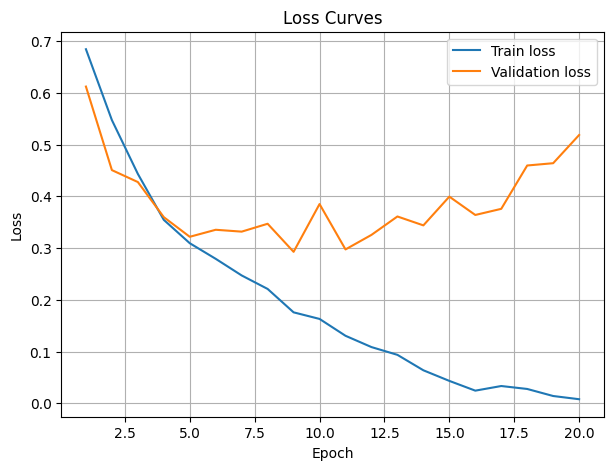

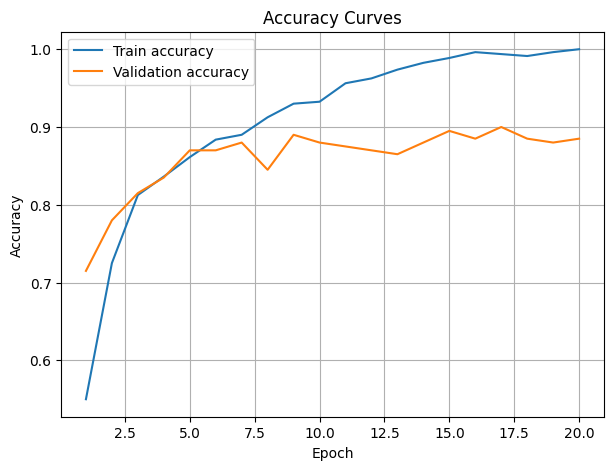

In [10]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(7,5))
plt.plot(epochs_range, history['train_loss'], label='Train loss')
plt.plot(epochs_range, history['validation_loss'], label='Validation loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves'); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs_range, history['train_accuracy'], label='Train accuracy')
plt.plot(epochs_range, history['validation_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curves'); plt.legend(); plt.grid(True); plt.show()


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [13]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [14]:
cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[86 14]
 [ 5 95]]


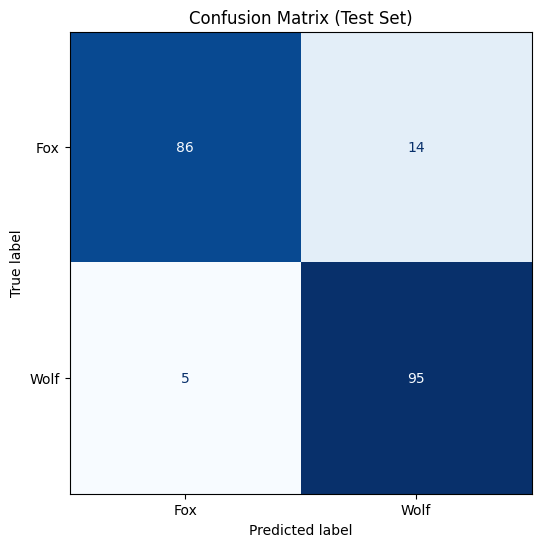

In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fox", "Wolf"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)

plt.title("Confusion Matrix (Test Set)")
plt.show()

In [16]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Fox", "Wolf"]
    )
)

              precision    recall  f1-score   support

         Fox       0.95      0.86      0.90       100
        Wolf       0.87      0.95      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



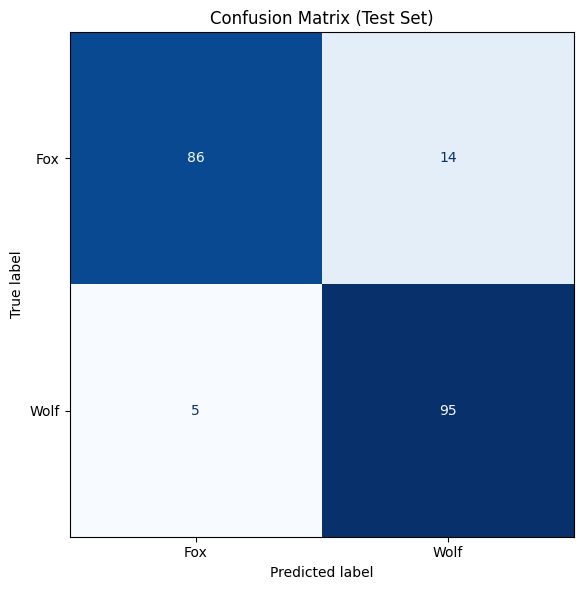

In [17]:
fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fox", "Wolf"]
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix_clean_baseline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final test evaluation

In [19]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
test_loss, test_accuracy = evaluate(model, test_loader)
print('Best epoch:', checkpoint['epoch'])
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

results = {
    'model': 'SimpleCNN',
    'experiment': 'clean_baseline',
    'seed': SEED,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'best_validation_accuracy': float(checkpoint['validation_accuracy']),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
}
results_path = OUTPUT_DIR / 'simple_cnn_clean_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)
print('Results saved to:', results_path)


Best epoch: 17
Test loss: 0.3125
Test accuracy: 0.9050
Results saved to: /content/drive/MyDrive/NMA_Occlusion_Project/simple_cnn_clean_results.json


# Phase 5: ResNet18 Clean Baseline

This phase trains a ResNet18 model using exactly the same clean fox/wolf train, validation, and test splits used for the SimpleCNN. This makes the comparison between the two models fair.


## Define a CIFAR-compatible ResNet18

The standard ResNet18 was designed for much larger ImageNet images. CIFAR-100 images are only 32 × 32, so the first convolution is changed to a 3 × 3 convolution with stride 1, and the initial max-pooling layer is removed.


In [28]:
from torchvision import models

def create_resnet18(num_classes=2):
    model = models.resnet18(weights=None)

    # Adapt ResNet18 for 32 x 32 CIFAR images.
    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )

    # The original max-pooling layer would shrink CIFAR images too quickly.
    model.maxpool = nn.Identity()

    # Replace the 1000-class ImageNet output with fox/wolf outputs.
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

resnet18 = create_resnet18(num_classes=2).to(device)
print(resnet18)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [33]:
evaluate

<function __main__.evaluate(model, loader)>

In [35]:
def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path,
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
    }

    best_validation_accuracy = -1.0

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total

        validation_loss, validation_accuracy = evaluate(
            model,
            validation_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "validation_accuracy": validation_accuracy,
                    "label_map": {0: "fox", 1: "wolf"},
                },
                checkpoint_path,
            )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.4f} | "
            f"Validation loss: {validation_loss:.4f} | "
            f"Validation accuracy: {validation_accuracy:.4f}"
        )

    return history

In [37]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [38]:
print("evaluate" in globals())
print("train_model" in globals())

True
True


## Train ResNet18

A fresh optimizer must be created for ResNet18 because its parameters are different from those of the SimpleCNN.


In [39]:
resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = torch.optim.Adam(
    resnet18.parameters(),
    lr=LEARNING_RATE,
)

resnet_checkpoint_path = OUTPUT_DIR / 'resnet18_clean_best.pt'

resnet_history = train_model(
    model=resnet18,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=resnet_criterion,
    optimizer=resnet_optimizer,
    device=device,
    epochs=EPOCHS,
    checkpoint_path=resnet_checkpoint_path,
)

print('Best ResNet18 model saved to:', resnet_checkpoint_path)


Epoch 01/20 | Train loss: 0.5872 | Train accuracy: 0.7438 | Validation loss: 0.6020 | Validation accuracy: 0.7650
Epoch 02/20 | Train loss: 0.4068 | Train accuracy: 0.7987 | Validation loss: 1.5060 | Validation accuracy: 0.5300
Epoch 03/20 | Train loss: 0.3374 | Train accuracy: 0.8488 | Validation loss: 0.3336 | Validation accuracy: 0.8750
Epoch 04/20 | Train loss: 0.3127 | Train accuracy: 0.8712 | Validation loss: 0.4580 | Validation accuracy: 0.8450
Epoch 05/20 | Train loss: 0.2386 | Train accuracy: 0.8988 | Validation loss: 0.3842 | Validation accuracy: 0.8850
Epoch 06/20 | Train loss: 0.2044 | Train accuracy: 0.9237 | Validation loss: 0.3250 | Validation accuracy: 0.8600
Epoch 07/20 | Train loss: 0.1263 | Train accuracy: 0.9525 | Validation loss: 0.3758 | Validation accuracy: 0.8350
Epoch 08/20 | Train loss: 0.1477 | Train accuracy: 0.9413 | Validation loss: 0.4948 | Validation accuracy: 0.8600
Epoch 09/20 | Train loss: 0.1621 | Train accuracy: 0.9337 | Validation loss: 0.3176 | Va

In [44]:
resnet_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location=device
)

resnet18.load_state_dict(
    resnet_checkpoint["model_state_dict"]
)

resnet_test_loss, resnet_test_accuracy = evaluate(
    model=resnet18,
    data_loader=test_loader,
    criterion=resnet_criterion,
    device=device,
)

print(f"ResNet18 test loss: {resnet_test_loss:.4f}")
print(f"ResNet18 test accuracy: {resnet_test_accuracy:.4f}")

ResNet18 test loss: 0.4448
ResNet18 test accuracy: 0.8950


In [45]:
resnet_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location=device
)

resnet18.load_state_dict(
    resnet_checkpoint["model_state_dict"]
)

print("Loaded checkpoint epoch:",
      resnet_checkpoint["epoch"])

print(
    "Best validation accuracy:",
    resnet_checkpoint["validation_accuracy"]
)

Loaded checkpoint epoch: 7
Best validation accuracy: 0.885


In [46]:
best_index = max(
    range(len(resnet_history["validation_accuracy"])),
    key=lambda i: resnet_history["validation_accuracy"][i]
)

print("Best epoch in current history:", best_index + 1)
print(
    "Best validation accuracy in current history:",
    resnet_history["validation_accuracy"][best_index]
)

Best epoch in current history: 7
Best validation accuracy in current history: 0.885


## Plot ResNet18 learning curves


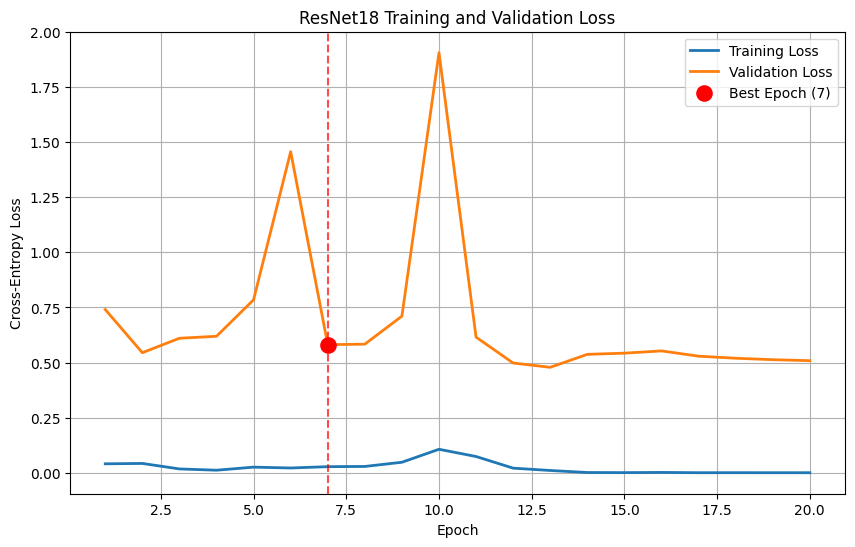

In [48]:
import matplotlib.pyplot as plt

# Find the best epoch based on validation accuracy
best_epoch = max(
    range(len(resnet_history["validation_accuracy"])),
    key=lambda i: resnet_history["validation_accuracy"][i]
)

epochs = range(1, len(resnet_history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))

# Plot loss curves
plt.plot(
    epochs,
    resnet_history["train_loss"],
    label="Training Loss",
    linewidth=2,
)

plt.plot(
    epochs,
    resnet_history["validation_loss"],
    label="Validation Loss",
    linewidth=2,
)

# Highlight the best epoch
plt.scatter(
    best_epoch + 1,
    resnet_history["validation_loss"][best_epoch],
    color="red",
    s=120,
    zorder=5,
    label=f"Best Epoch ({best_epoch + 1})"
)

plt.axvline(
    x=best_epoch + 1,
    color="red",
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("ResNet18 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

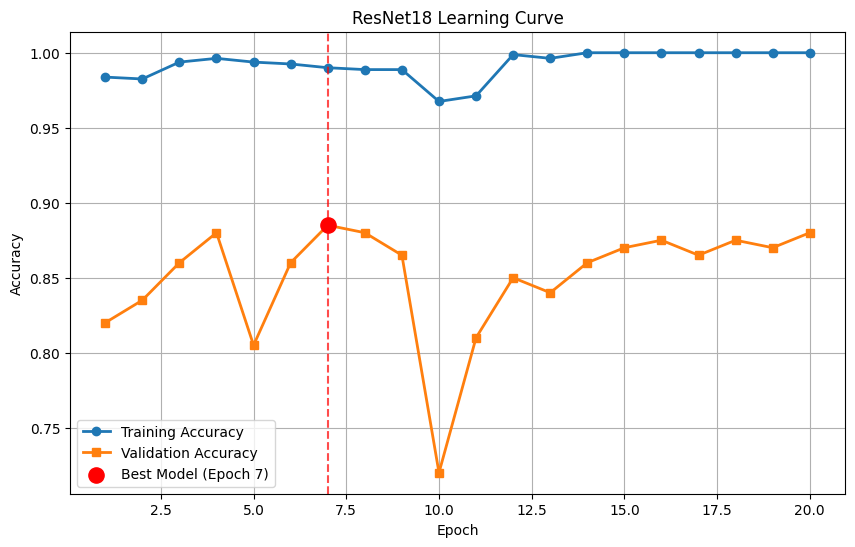

In [51]:
import matplotlib.pyplot as plt

best_epoch = max(
    range(len(resnet_history["validation_accuracy"])),
    key=lambda i: resnet_history["validation_accuracy"][i]
)

epochs = range(1, len(resnet_history["train_accuracy"]) + 1)

plt.figure(figsize=(10,6))

plt.plot(
    epochs,
    resnet_history["train_accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    resnet_history["validation_accuracy"],
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.scatter(
    best_epoch + 1,
    resnet_history["validation_accuracy"][best_epoch],
    color="red",
    s=120,
    zorder=5,
    label=f"Best Model (Epoch {best_epoch+1})"
)

plt.axvline(
    best_epoch + 1,
    color="red",
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

## Interpretation
The Resnet18 learning curve Training accuracy increased rapidly and approached 100% within the first several epochs, demonstrating the model's ability to fit the training data. Validation accuracy also improved during the early epochs, reaching its highest value of 88.5% at epoch 7. Beyond this point, training accuracy continued to increase while validation accuracy fluctuated without further improvement, indicating the onset of overfitting. Consequently, the model checkpoint from epoch 7 was selected as the final model for test evaluation.

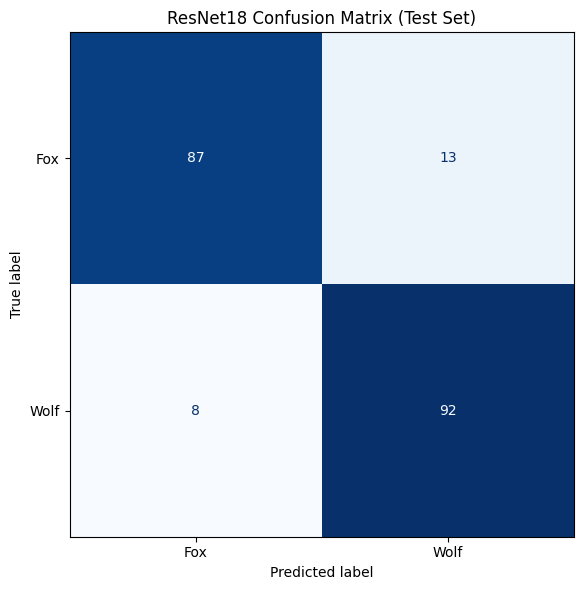


Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

         Fox     0.9158    0.8700    0.8923       100
        Wolf     0.8762    0.9200    0.8976       100

    accuracy                         0.8950       200
   macro avg     0.8960    0.8950    0.8949       200
weighted avg     0.8960    0.8950    0.8949       200



In [49]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
import matplotlib.pyplot as plt
import torch

# Put model in evaluation mode
resnet18.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet18(images)
        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fox", "Wolf"]
)
disp.plot(
    cmap="Blues",
    values_format="d",
    ax=plt.gca(),
    colorbar=False,
)

plt.title("ResNet18 Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report")
print("-" * 60)
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Fox", "Wolf"],
        digits=4,
    )
)

In [53]:
import pandas as pd



cnn_accuracy = 0.91
cnn_precision = 0.91
cnn_recall = 0.91
cnn_f1 = 0.90

# ==============================
# ResNet18 results
# ==============================

resnet_accuracy = 0.8950
resnet_precision = 0.8960
resnet_recall = 0.8950
resnet_f1 = 0.8949

comparison_df = pd.DataFrame({
    "Model": ["Simple CNN", "ResNet18"],
    "Accuracy": [cnn_accuracy, resnet_accuracy],
    "Precision": [cnn_precision, resnet_precision],
    "Recall": [cnn_recall, resnet_recall],
    "F1-score": [cnn_f1, resnet_f1]
})

# Convert to percentages
comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:] * 100

# Round values
comparison_df = comparison_df.round(2)

print("\nBaseline Model Comparison")
display(comparison_df)


Baseline Model Comparison


,Model,Accuracy,Precision,Recall,F1-score
0,Simple CNN,91.0,91.0,91.0,90.00
1,ResNet18,89.5,89.6,89.5,89.49


In [55]:
resnet_checkpoint = torch.load(resnet_checkpoint_path, map_location=device)
resnet18.load_state_dict(resnet_checkpoint['model_state_dict'])

print('Loaded ResNet18 checkpoint from epoch:', resnet_checkpoint['epoch'])
print('Best validation accuracy:', resnet_checkpoint['validation_accuracy'])

resnet_test_loss, resnet_test_accuracy = evaluate(
    model=resnet18,
    data_loader=test_loader,
    criterion=resnet_criterion,
    device=device,
)

print(f'ResNet18 test loss: {resnet_test_loss:.4f}')
print(f'ResNet18 test accuracy: {resnet_test_accuracy:.4f}')


Loaded ResNet18 checkpoint from epoch: 7
Best validation accuracy: 0.885
ResNet18 test loss: 0.4448
ResNet18 test accuracy: 0.8950


In [57]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

def evaluate_with_confusion_matrix(
    model,
    data_loader,
    device,
    model_name,
    output_dir=None,
):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    cm = confusion_matrix(all_labels, all_predictions, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(6, 6))
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Fox', 'Wolf'],
    )
    display.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name}: Test Confusion Matrix')
    plt.tight_layout()

    if output_dir is not None:
        safe_name = model_name.lower().replace(' ', '_')
        figure_path = Path(output_dir) / f'{safe_name}_confusion_matrix.png'
        fig.savefig(figure_path, dpi=300, bbox_inches='tight')
        print('Confusion matrix saved to:', figure_path)

    plt.show()

    report = classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1],
        target_names=['Fox', 'Wolf'],
        output_dict=True,
        zero_division=0,
    )

    print(classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1],
        target_names=['Fox', 'Wolf'],
        zero_division=0,
    ))

    return cm, report


Confusion matrix saved to: /content/drive/MyDrive/NMA_Occlusion_Project/simplecnn_confusion_matrix.png


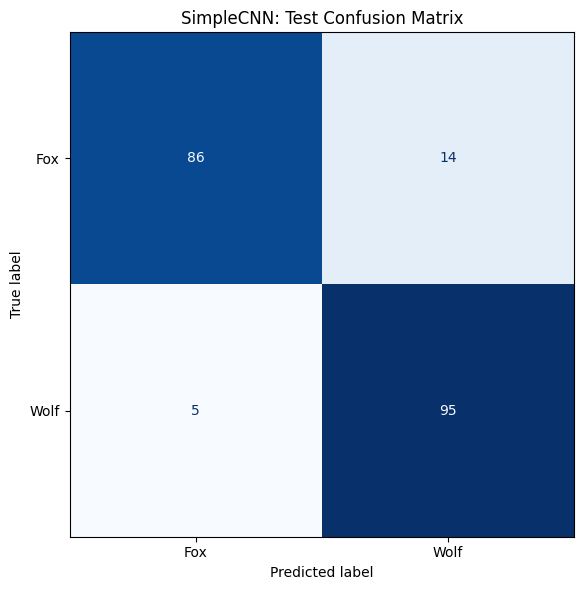

              precision    recall  f1-score   support

         Fox       0.95      0.86      0.90       100
        Wolf       0.87      0.95      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



In [58]:
# Reload the best SimpleCNN checkpoint before evaluating it.
simple_cnn_checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(simple_cnn_checkpoint['model_state_dict'])

simple_cnn_cm, simple_cnn_report = evaluate_with_confusion_matrix(
    model=model,
    data_loader=test_loader,
    device=device,
    model_name='SimpleCNN',
    output_dir=OUTPUT_DIR,
)


Confusion matrix saved to: /content/drive/MyDrive/NMA_Occlusion_Project/resnet18_confusion_matrix.png


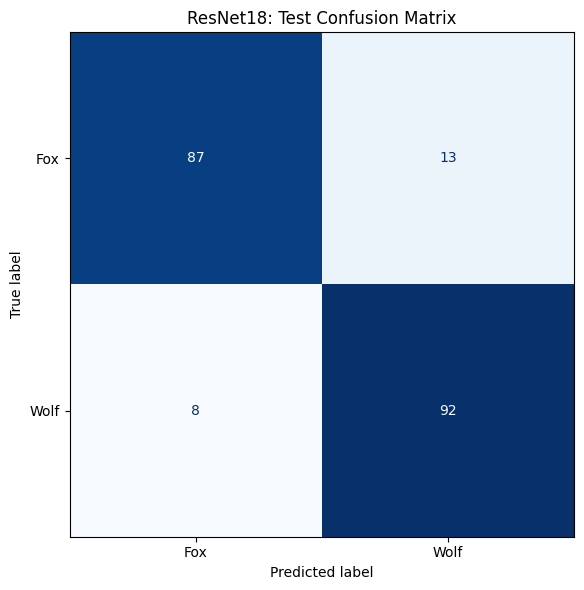

              precision    recall  f1-score   support

         Fox       0.92      0.87      0.89       100
        Wolf       0.88      0.92      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200



In [59]:
resnet_cm, resnet_report = evaluate_with_confusion_matrix(
    model=resnet18,
    data_loader=test_loader,
    device=device,
    model_name='ResNet18',
    output_dir=OUTPUT_DIR,
)


In [60]:
import pandas as pd

comparison = pd.DataFrame([
    {
        'Model': 'SimpleCNN',
        'Best validation accuracy': float(simple_cnn_checkpoint['validation_accuracy']),
        'Test accuracy': float(test_accuracy),
        'Fox precision': simple_cnn_report['Fox']['precision'],
        'Fox recall': simple_cnn_report['Fox']['recall'],
        'Fox F1': simple_cnn_report['Fox']['f1-score'],
        'Wolf precision': simple_cnn_report['Wolf']['precision'],
        'Wolf recall': simple_cnn_report['Wolf']['recall'],
        'Wolf F1': simple_cnn_report['Wolf']['f1-score'],
    },
    {
        'Model': 'ResNet18',
        'Best validation accuracy': float(resnet_checkpoint['validation_accuracy']),
        'Test accuracy': float(resnet_test_accuracy),
        'Fox precision': resnet_report['Fox']['precision'],
        'Fox recall': resnet_report['Fox']['recall'],
        'Fox F1': resnet_report['Fox']['f1-score'],
        'Wolf precision': resnet_report['Wolf']['precision'],
        'Wolf recall': resnet_report['Wolf']['recall'],
        'Wolf F1': resnet_report['Wolf']['f1-score'],
    },
])

comparison = comparison.round(4)
display(comparison)

comparison_path = OUTPUT_DIR / 'clean_baseline_model_comparison.csv'
comparison.to_csv(comparison_path, index=False)
print('Comparison saved to:', comparison_path)


,Model,Best validation accuracy,Test accuracy,Fox precision,Fox recall,Fox F1,Wolf precision,Wolf recall,Wolf F1
0,SimpleCNN,0.900,0.905,0.9451,0.86,0.9005,0.8716,0.95,0.9091
1,ResNet18,0.885,0.895,0.9158,0.87,0.8923,0.8762,0.92,0.8976


Comparison saved to: /content/drive/MyDrive/NMA_Occlusion_Project/clean_baseline_model_comparison.csv


In [61]:
resnet_results = {
    'model': 'ResNet18',
    'experiment': 'clean_baseline',
    'seed': SEED,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'best_validation_accuracy': float(resnet_checkpoint['validation_accuracy']),
    'test_loss': float(resnet_test_loss),
    'test_accuracy': float(resnet_test_accuracy),
    'fox_precision': float(resnet_report['Fox']['precision']),
    'fox_recall': float(resnet_report['Fox']['recall']),
    'fox_f1': float(resnet_report['Fox']['f1-score']),
    'wolf_precision': float(resnet_report['Wolf']['precision']),
    'wolf_recall': float(resnet_report['Wolf']['recall']),
    'wolf_f1': float(resnet_report['Wolf']['f1-score']),
}

resnet_results_path = OUTPUT_DIR / 'resnet18_clean_results.json'

with open(resnet_results_path, 'w') as file:
    json.dump(resnet_results, file, indent=4)

print('ResNet18 results saved to:', resnet_results_path)
print(resnet_results)


ResNet18 results saved to: /content/drive/MyDrive/NMA_Occlusion_Project/resnet18_clean_results.json
{'model': 'ResNet18', 'experiment': 'clean_baseline', 'seed': 42, 'epochs': 20, 'batch_size': 64, 'learning_rate': 0.001, 'best_validation_accuracy': 0.885, 'test_loss': 0.44481628817506136, 'test_accuracy': 0.895, 'fox_precision': 0.9157894736842105, 'fox_recall': 0.87, 'fox_f1': 0.8923076923076924, 'wolf_precision': 0.8761904761904762, 'wolf_recall': 0.92, 'wolf_f1': 0.8975609756097561}


## Plot ResNet18 learning curves
